# Validation of kinGEMs iML1515 Models

This notebook uses the validation utility functions to analyze kinGEMs-produced iML1515 models and compare them with experimental data.

## 1. Load Required Libraries and Functions

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import cobra
import matplotlib.pyplot as plt

# Add parent directory to path to import kinGEMs
sys.path.append(os.path.abspath('..'))

from kinGEMs.validation_utils import (
    prepare_model,
    load_environment,
    load_data,
    match_model_data,
    model_adjustments,
    check_environment,
    test_growth,
    simulate_phenotype,
    simulate_phenotype_flux,
    calculate_phenotypes_with_dataframe
)

from kinGEMs.config import ECOLI_VALIDATION_DIR, MODELS_DIR

# Silence warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Import Model and Experimental Data

Load your kinGEMs-produced model and the experimental growth data.

In [4]:
# Load the genome-scale model
model_path = os.path.join(MODELS_DIR, 'ecoli_iML1515_20250826_4941.xml')
model = cobra.io.read_sbml_model(model_path)

print("Genes in saved model:", len(model.genes))

# Load experimental data from ECOLI_VALIDATION_DIR
data_dir = ECOLI_VALIDATION_DIR

# Load experimental validation data (Keio fitness)
keio_fitness_path = os.path.join(data_dir, 'fit_organism_Keio.tsv')
keio_fitness_data = pd.read_table(keio_fitness_path)

Genes in saved model: 1516


In [5]:
# Diagnostic: Print gene and reaction counts after model load
print("[Step] After loading model:")
print("  Genes in model:", len(model.genes))
print("  Reactions in model:", len(model.reactions))
model_gene_ids = set([g.id for g in model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])

# Diagnostic: Print kcat coverage if available
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After loading model:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b2687', 'b2010', 'b2037', 'b0010', 'b0367', 'b0592', 'b4515', 'b0822', 'b0914', 'b1380']
  First 10 reaction IDs: ['NADS1', 'NADN', 'HACD5', 'HKNDDH', 'LYXt2pp', 'ACt2rpp', 'XPPT', 'ASPtex', 'SO2tpp', 'EX_rib__D_e']
  Reactions with kcat: 2136
  Reactions without kcat: 576


## 3. Apply Validation Functions

Match model components with experimental data and perform initial validations.

In [ ]:
# 1. Prepare model (set exchange bounds)
model = prepare_model(model)

# 2. Load environment (medium and carbon sources)
name_medium_model, name_carbon_model, name_carbon_experiment = load_environment(ECOLI_VALIDATION_DIR)

# 3. Load experimental data
data_experiments, data_genes, data_fitness = load_data(ECOLI_VALIDATION_DIR)

# 4. Match model and data
name_genes_matched, name_carbon_experiment_matched, name_carbon_model_matched, data_fitness_matched = match_model_data(
    model=model,
    name_carbon_model=name_carbon_model,
    name_carbon_experiment=name_carbon_experiment,
    data_experiments=data_experiments,
    data_genes=data_genes,
    data_fitness=data_fitness
)

# 5. Adjust model and matched data
model_adj, name_genes_matched_adj, name_carbon_experiment_matched_adj, name_carbon_model_matched_adj, data_fitness_matched_adj = model_adjustments(
    adj_strain=True,
    adj_essential=True,
    adj_carbon=True,
    model=model,
    name_genes_matched=name_genes_matched,
    name_carbon_experiment_matched=name_carbon_experiment_matched,
    name_carbon_model_matched=name_carbon_model_matched,
    data_fitness_matched=data_fitness_matched
)

# 6. Check environment setup
medium_ex_inds, carbon_ex_inds = check_environment(
    model_adj=model_adj,
    name_medium_model=name_medium_model,
    name_carbon_model_matched_adj=name_carbon_model_matched_adj
)

Matching model genes to data genes...
Matched 1339 genes.
Matching experimental carbon sources to model carbon sources...
Matched 54 carbon sources.
Shape of matched fitness data: (1339, 54)
Averaging fitness data for replicate carbon sources...
Final shape of averaged fitness data: (1339, 27)
Unique carbon sources after averaging: 27
Matched 1339 genes.
Matching experimental carbon sources to model carbon sources...
Matched 54 carbon sources.
Shape of matched fitness data: (1339, 54)
Averaging fitness data for replicate carbon sources...
Final shape of averaged fitness data: (1339, 27)
Unique carbon sources after averaging: 27


In [4]:
# Debug gene matching before running match_model_data
print("Total genes in model:", len(model.genes))
print("Total genes in experimental data:", len(data_genes))
model_gene_ids = set([g.id for g in model.genes])
data_gene_ids = set(data_genes)
unmatched = data_gene_ids - model_gene_ids
print("Unmatched data gene IDs (first 10):", list(unmatched)[:10])

Total genes in model: 137
Total genes in experimental data: 3789
Unmatched data gene IDs (first 10): ['b3089', 'b3817', 'b3856', 'b3491', 'b1754', 'b1956', 'b3350', 'b3512', 'b0534', 'b1132']


## 4. Test Growth Predictions

Analyze model growth predictions and compare with experimental data.

In [4]:
# 6. Test growth and simulate phenotypes
growth_results = test_growth(
    model_adj=model_adj,
    name_carbon_model_matched_adj=name_carbon_model_matched_adj,
    medium_ex_inds=medium_ex_inds,
    carbon_ex_inds=carbon_ex_inds
)

data_fitness_simulated = simulate_phenotype(
    model_run=model_adj,
    name_genes_matched_adj=name_genes_matched_adj,
    name_carbon_model_matched_adj=name_carbon_model_matched_adj,
    medium_ex_inds=medium_ex_inds,
    carbon_ex_inds=carbon_ex_inds
)


## 5. Analyze Model Performance

Calculate performance metrics and visualize results.

Model Performance Metrics:
Accuracy: 0.398
Precision: 0.398
Recall: 1.000
F1 Score: 0.569


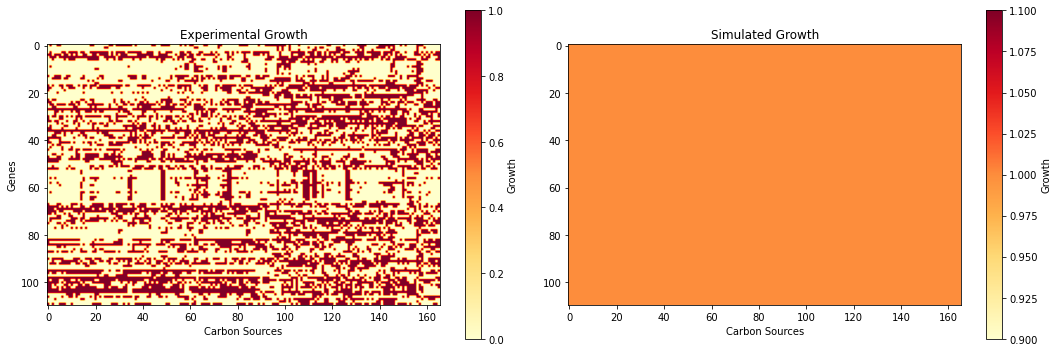

In [5]:
# Create binary growth matrices (threshold at 0.001)
thresh = 0.001
exp_binary = (data_fitness_matched_adj > 0).astype(float)  # Use matched/adjusted experimental data
sim_binary = (data_fitness_simulated > thresh).astype(float)

# Calculate accuracy metrics
true_pos = np.sum((exp_binary == 1) & (sim_binary == 1))
true_neg = np.sum((exp_binary == 0) & (sim_binary == 0))
false_pos = np.sum((exp_binary == 0) & (sim_binary == 1))
false_neg = np.sum((exp_binary == 1) & (sim_binary == 0))

accuracy = (true_pos + true_neg) / np.prod(exp_binary.shape)
precision = true_pos / (true_pos + false_pos)
recall = true_pos / (true_pos + false_neg)
f1_score = 2 * (precision * recall) / (precision + recall)

print('Model Performance Metrics:')
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1_score:.3f}')

# Plot comparison heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

im1 = ax1.imshow(exp_binary, cmap='YlOrRd')
ax1.set_title('Experimental Growth')
ax1.set_xlabel('Carbon Sources')
ax1.set_ylabel('Genes')

im2 = ax2.imshow(sim_binary, cmap='YlOrRd')
ax2.set_title('Simulated Growth')
ax2.set_xlabel('Carbon Sources')

plt.colorbar(im1, ax=ax1, label='Growth')
plt.colorbar(im2, ax=ax2, label='Growth')
plt.tight_layout()
plt.show()

## 6. Calculate Detailed Flux Phenotypes (Optional)

For more detailed analysis, calculate flux distributions for each condition.

In [7]:
# Print input shapes and sample values for debugging
print("Number of genes (matched/adj):", len(name_genes_matched_adj))
print("Number of carbon sources (matched/adj):", len(name_carbon_model_matched_adj))
print("Medium exchange indices:", medium_ex_inds)
print("Carbon exchange indices:", carbon_ex_inds)
print("First 5 gene IDs:", name_genes_matched_adj[:5])
print("First 5 carbon sources:", name_carbon_model_matched_adj[:5])

# Load processed_df, objective_reaction, and enzyme_upper_bound as needed for enzyme-constrained simulation
# Example:
# processed_df = pd.read_csv('path_to_processed_df.csv')
# objective_reaction = 'BIOMASS_Ecoli_core_w_GAM'
# enzyme_upper_bound = 0.125

# Calculate flux phenotypes for both baseline and enzyme-constrained GEMs (this may take some time)
baseline_flux, enzyme_constrained_flux = simulate_phenotype_flux(
    model_run=model_adj,
    name_genes_matched_adj=name_genes_matched_adj,
    name_carbon_model_matched_adj=name_carbon_model_matched_adj,
    medium_ex_inds=medium_ex_inds,
    carbon_ex_inds=carbon_ex_inds,
    processed_df=processed_df,
    objective_reaction=objective_reaction,
    enzyme_upper_bound=enzyme_upper_bound,
    thresh=0.001
    # Add any other required arguments here
    )

print("Flux phenotype calculation complete.")
print("Shape of baseline flux data:", baseline_flux.shape)
print("Shape of enzyme-constrained flux data:", enzyme_constrained_flux.shape)
print("(n_genes × n_carbon_sources × n_reactions)")
print("Sample baseline flux values for first gene, first carbon source:", baseline_flux[0, 0, :5])
print("Sample enzyme-constrained flux values for first gene, first carbon source:", enzyme_constrained_flux[0, 0, :5])

# Save results
os.makedirs('../results/validation', exist_ok=True)
np.save('../results/validation/baseline_flux_phenotypes.npy', baseline_flux)
np.save('../results/validation/enzyme_constrained_flux_phenotypes.npy', enzyme_constrained_flux)
print("Baseline flux phenotype results saved to ../results/validation/baseline_flux_phenotypes.npy")
print("Enzyme-constrained flux phenotype results saved to ../results/validation/enzyme_constrained_flux_phenotypes.npy")

Number of genes (matched/adj): 110
Number of carbon sources (matched/adj): 166
Medium exchange indices: [16 17 15 -1]
Carbon exchange indices: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
First 5 gene IDs: ['b0008' 'b0114' 'b0118' 'b0351' 'b0356']
First 5 carbon sources: ['set1IT003', 'set1IT004', 'set1IT005', 'set1IT006', 'set1IT007']
Flux phenotype calculation complete.
Shape of flux data: (110, 166, 154)
(n_genes × n_carbon_sources × n_reactions)
Sample flux values for first gene, first carbon source: [0.06803157 0.         0.    